# Electricity Incident Prediction - Quick EDA and Results

This notebook helps inspect the generated dataset and baseline model behavior.

## Raw demand dataset

Auxiliary functions to plot data from raw and supervised datasets

In [190]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DEMAND_PATH = ROOT / "data" / "raw" / "demand_2021_2025.csv"
SUP_PATH    = ROOT / "data" / "processed" / "supervised_2021_2025.csv"

def load_demand(path: Path | str = None):
    path = Path(path) if path is not None else DEMAND_PATH
    df = pd.read_csv(path)
    date_candidates = [c for c in df.columns if any(k in c.lower() for k in ("time", "date", "ts", "datetime"))]
    date_col = date_candidates[0] if date_candidates else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", utc=True)
    df = df.set_index(date_col).sort_index()
    demand_candidates = [c for c in df.columns if any(k in c.lower() for k in ("demand", "load", "mw"))]
    if not demand_candidates:
        demand_candidates = df.select_dtypes("number").columns.tolist()
    demand_col = demand_candidates[0]
    return df, demand_col

def load_incidents(path: Path | str = None):
    path = Path(path) if path is not None else SUP_PATH
    sup = pd.read_csv(path)
    # expect a timestamp column named like 'timestamp_target_start'
    ts_col = next((c for c in sup.columns if "timestamp" in c.lower()), None)
    if ts_col is None:
        raise ValueError("Could not find a timestamp column in supervised file")
    sup[ts_col] = pd.to_datetime(sup[ts_col], errors="coerce", utc=True)
    incidents = sup[sup.get("target", 0) == 1].copy()
    incidents = incidents.rename(columns={ts_col: "ts"})
    incidents = incidents.sort_values("ts")
    return incidents

def plot_demand(df, demand_col, incidents=None, start_date=None, end_date=None,
                ax=None, figsize=(14,4), title=None, incident_marker=dict(color="red", s=30, zorder=5)):
    start = pd.to_datetime(start_date, utc=True) if start_date is not None else df.index.min()
    end   = pd.to_datetime(end_date,   utc=True) if end_date   is not None else df.index.max()
    start = max(start, df.index.min())
    end   = min(end, df.index.max())
    if start > end:
        raise ValueError("start_date must be before end_date after clipping to data range")
    subset = df.loc[start:end, demand_col]

    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_ax = True

    subset.plot(ax=ax, label="Demand")
    ax.set_xlabel("Time")
    ax.set_ylabel(demand_col)

    if incidents is not None and not incidents.empty:
        # get incident timestamps in range
        inc_ts = pd.to_datetime(incidents["ts"], utc=True)
        inc_ts = inc_ts[(inc_ts >= start) & (inc_ts <= end)]
        if not inc_ts.empty:
            # pick demand values at/near incident timestamps (nearest index)
            demand_series = df[demand_col]
            # reindex with nearest (data is hourly)
            demand_at_inc = demand_series.reindex(inc_ts, method="nearest")
            ax.scatter(demand_at_inc.index, demand_at_inc.values,
                       label="Incidents", **incident_marker)
    ax.legend()
    ax.set_title(title or f"Demand ({start.date()} — {end.date()})")
    if created_ax:
        plt.tight_layout()
        plt.show()
    return ax

def plot_week_offset_periods(
    df,
    demand_col,
    reference_start,
    reference_end,
    weeks,
    labels=None,
    ax=None,
    figsize=(14, 5),
    title=None,
    legend_title="Periods",
):
    """
    Plot multiple periods from previous weeks in a single chart for direct comparison.

    Parameters
    ----------
    df : pd.DataFrame
        Time-indexed demand dataframe.
    demand_col : str
        Demand column name.
    reference_start, reference_end : str | datetime-like
        Base period boundaries (for example Tuesday 00:00 to Tuesday 23:00).
    weeks : list[int]
        Week offsets relative to the reference period.
        0 means current/reference period, 1 means 1 week before, 2 means 2 weeks before, etc.
    labels : list[str] | None
        Optional labels for each line; must match length of weeks.
    """
    if labels is not None and len(labels) != len(weeks):
        raise ValueError("labels must have the same length as weeks")

    ref_start = pd.to_datetime(reference_start, utc=True)
    ref_end = pd.to_datetime(reference_end, utc=True)
    if ref_start >= ref_end:
        raise ValueError("reference_start must be before reference_end")

    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_ax = True

    plotted = 0
    for i, week_offset in enumerate(weeks):
        # Compare against previous weeks: offset is subtracted from the reference period.
        offset_weeks = abs(int(week_offset))
        period_start = ref_start - pd.Timedelta(weeks=offset_weeks)
        period_end = ref_end - pd.Timedelta(weeks=offset_weeks)

        # Keep only data available in the dataframe bounds.
        period_start = max(period_start, df.index.min())
        period_end = min(period_end, df.index.max())
        if period_start >= period_end:
            continue

        subset = df.loc[period_start:period_end, demand_col]
        if subset.empty:
            continue

        elapsed_hours = (subset.index - subset.index[0]).total_seconds() / 3600.0
        iso_week = int(subset.index[0].isocalendar().week)
        default_label = f"Week {iso_week} ({subset.index[0].date()} to {subset.index[-1].date()})"
        line_label = labels[i] if labels is not None else default_label

        ax.plot(elapsed_hours, subset.values, label=line_label, linewidth=2)
        plotted += 1

    if plotted == 0:
        raise ValueError("No data points were found for the requested periods")

    ax.set_xlabel("Hours since period start")
    ax.set_ylabel(demand_col)
    ax.set_title(title or "Demand comparison with previous weeks")
    ax.grid(True, alpha=0.25)
    ax.legend(title=legend_title)

    if created_ax:
        plt.tight_layout()
        plt.show()

    return ax

In [191]:
df = pd.read_csv(DEMAND_PATH)
df.head()

,datetime,demand_mw
0,2021-01-01 00:00:00+01:00,24656.632
1,2021-01-01 01:00:00+01:00,23383.418
2,2021-01-01 02:00:00+01:00,21273.532
3,2021-01-01 03:00:00+01:00,19589.138
4,2021-01-01 04:00:00+01:00,18755.911


In [192]:
print("Rows:", len(df))

Rows: 43824


### Demand from 2021 to 2025

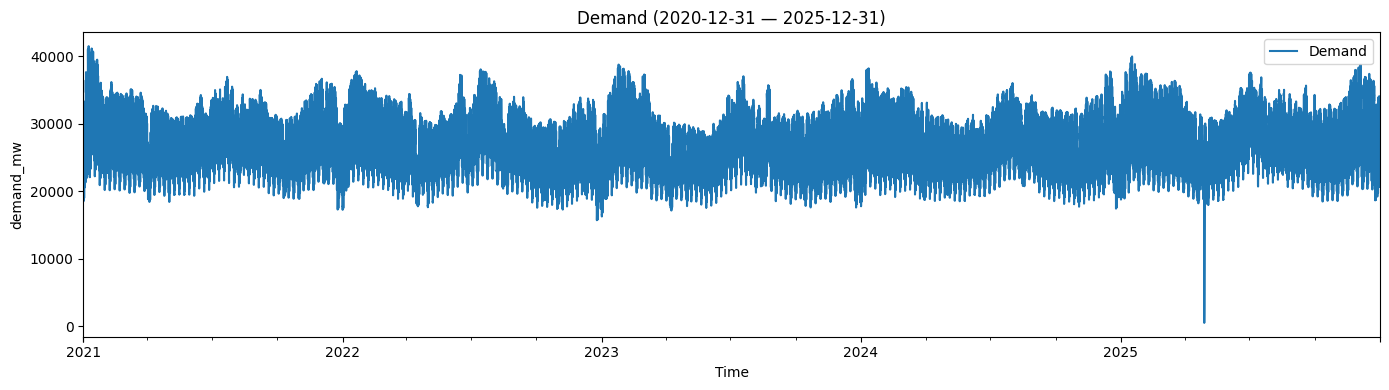

<Axes: title={'center': 'Demand (2020-12-31 — 2025-12-31)'}, xlabel='Time', ylabel='demand_mw'>

In [193]:
# load data
df_demand, demand_col = load_demand()

# whole timeline
plot_demand(df_demand, demand_col)

### Iberia power outage (2025-04-30)

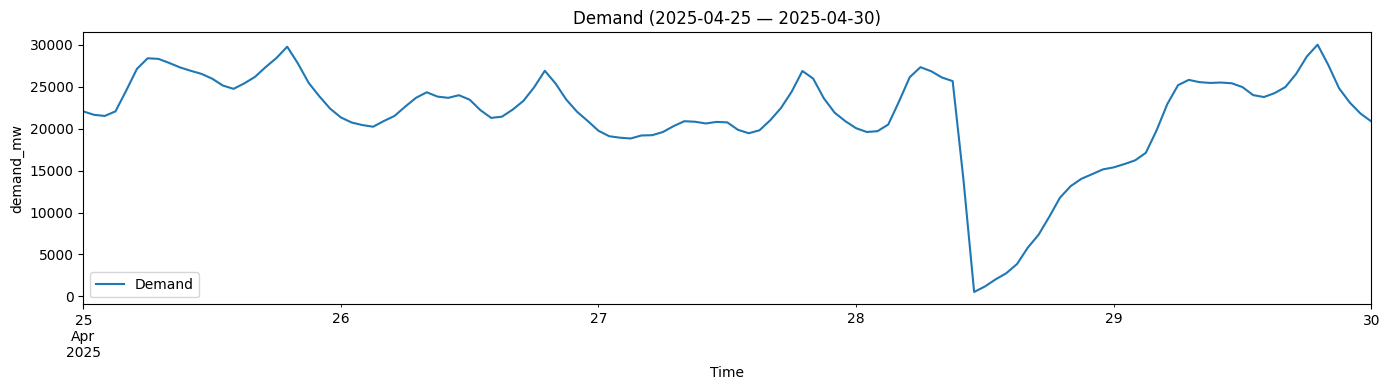

<Axes: title={'center': 'Demand (2025-04-25 — 2025-04-30)'}, xlabel='Time', ylabel='demand_mw'>

In [194]:
plot_demand(df_demand, demand_col, start_date='2025-04-25', end_date='2025-04-30')

### Anual comparison

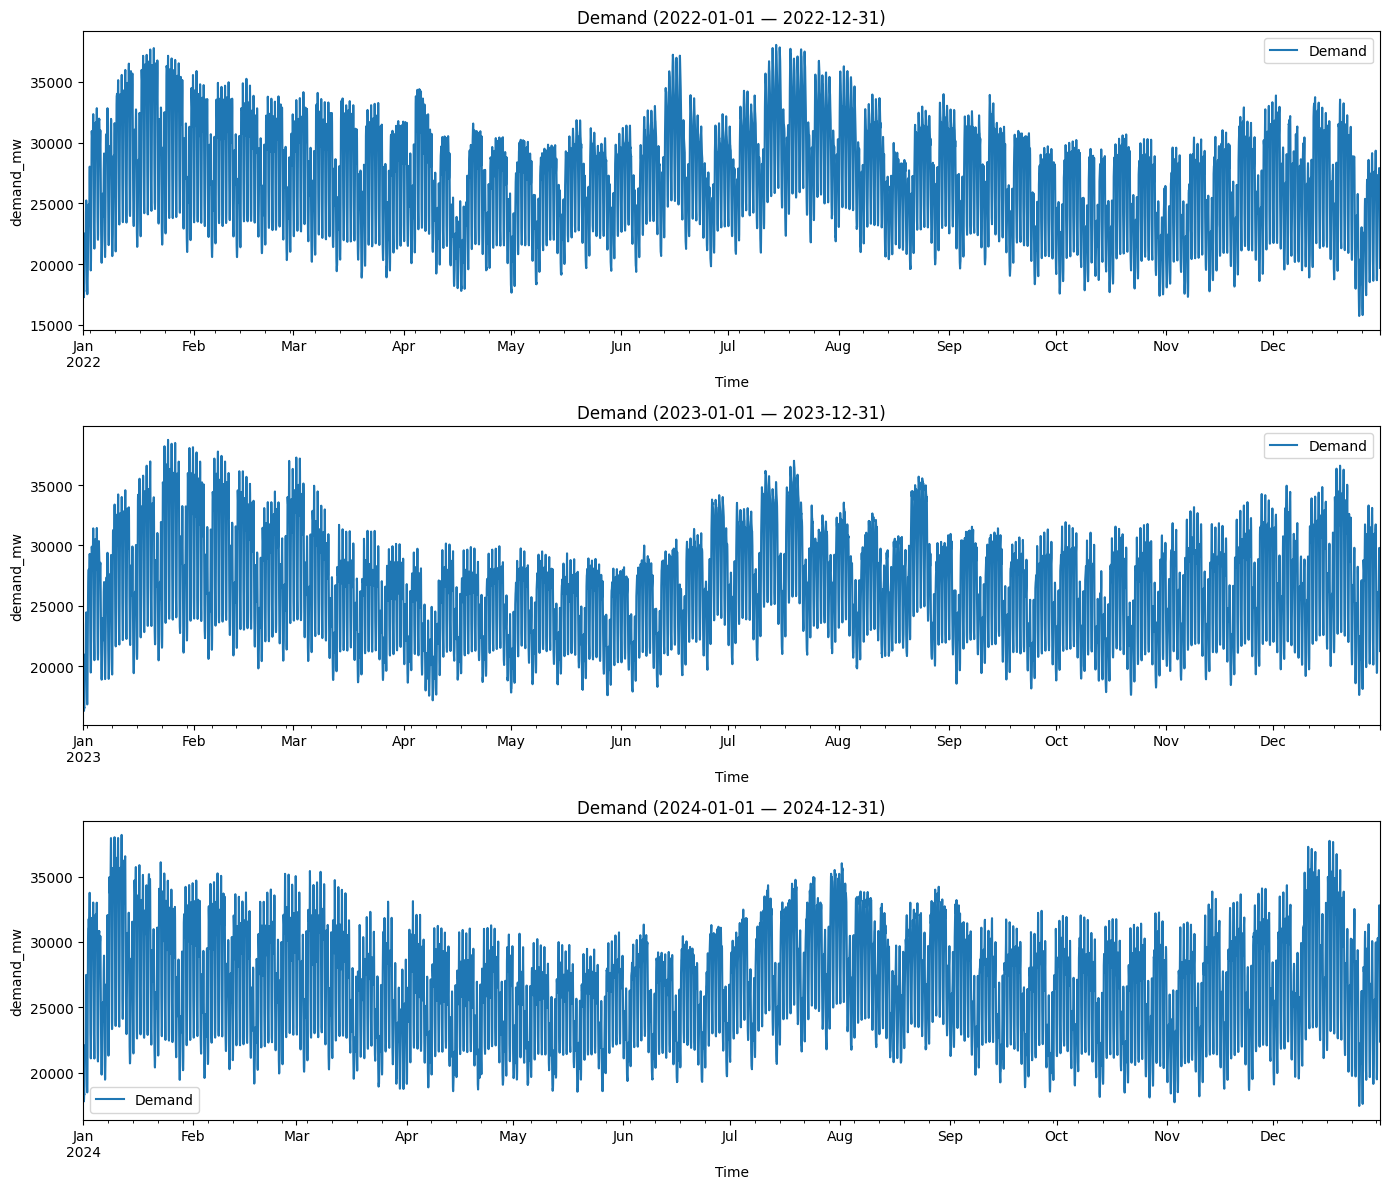

In [195]:
# multiple periods (stacked plots)
periods = [
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
    ("2024-01-01", "2024-12-31"),
]
fig, axes = plt.subplots(len(periods), 1, figsize=(14, 4 * len(periods)), squeeze=False)
for ax, (s, e) in zip(axes.ravel(), periods):
    plot_demand(df_demand, demand_col, start_date=s, end_date=e, ax=ax)
plt.tight_layout()
plt.show()

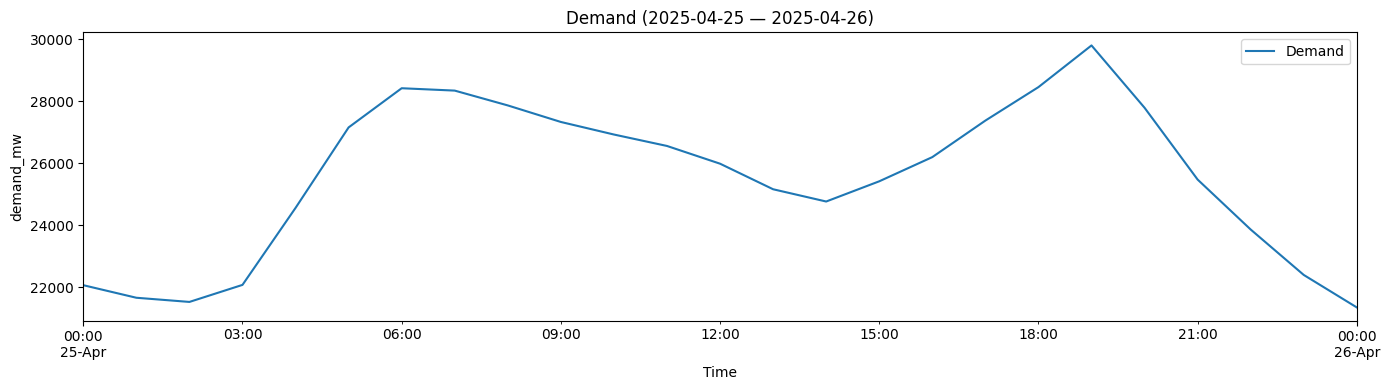

<Axes: title={'center': 'Demand (2025-04-25 — 2025-04-26)'}, xlabel='Time', ylabel='demand_mw'>

In [196]:
plot_demand(df_demand, demand_col, start_date="2025-04-25", end_date="2025-04-26")

## Incidents dataset

In [197]:
df = pd.read_csv(SUP_PATH)
df.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,target,timestamp_target_start
0,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,38437.059,39148.044,40392.968,...,19234.177,18764.257,18521.015,18755.911,19589.138,21273.532,23383.418,24656.632,0,2021-01-07T23:00:00Z
1,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,38437.059,39148.044,...,19394.375,19234.177,18764.257,18521.015,18755.911,19589.138,21273.532,23383.418,0,2021-01-08T00:00:00Z
2,26788.346,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,38437.059,...,20605.308,19394.375,19234.177,18764.257,18521.015,18755.911,19589.138,21273.532,0,2021-01-08T01:00:00Z
3,25473.496,26788.346,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,38427.044,...,22990.898,20605.308,19394.375,19234.177,18764.257,18521.015,18755.911,19589.138,0,2021-01-08T02:00:00Z
4,24862.779,25473.496,26788.346,29265.563,32154.515,35872.538,38906.749,39936.377,39838.223,39391.774,...,24930.918,22990.898,20605.308,19394.375,19234.177,18764.257,18521.015,18755.911,0,2021-01-08T03:00:00Z


In [198]:
print("Rows:", len(df))
print("Positive rate:", df["target"].mean())

Rows: 43650
Positive rate: 0.15967926689576173


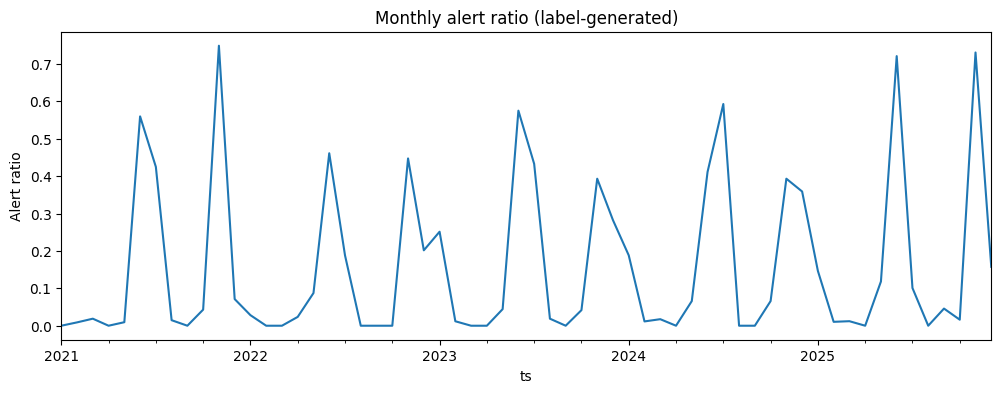

In [199]:
target_by_month = (
    df.assign(ts=pd.to_datetime(df["timestamp_target_start"]))
    .set_index("ts")["target"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(12, 4))
target_by_month.plot()
plt.title("Monthly alert ratio (label-generated)")
plt.ylabel("Alert ratio")
plt.show()

### When do alerts happen most?

Simple counts by weekday and month for rows labeled as alerts (`target == 1`).

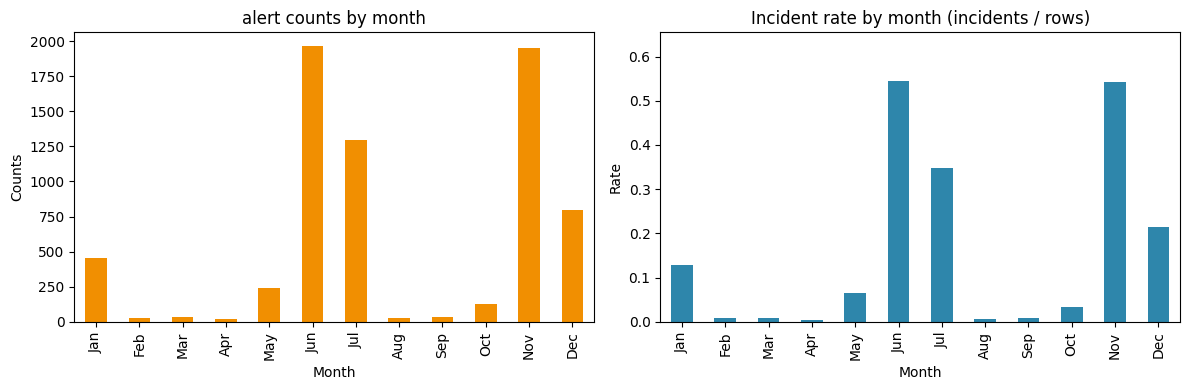

Month counts:
month
Jan     457
Feb      29
Mar      36
Apr      17
May     242
Jun    1964
Jul    1294
Aug      25
Sep      33
Oct     124
Nov    1953
Dec     796
Name: count, dtype: int64

Month rates:
month
Jan    0.128624
Feb    0.008570
Mar    0.009677
Apr    0.004722
May    0.065054
Jun    0.545556
Jul    0.347849
Aug    0.006720
Sep    0.009167
Oct    0.033333
Nov    0.542500
Dec    0.214382
Name: count, dtype: float64

Incidents per year x month:
month  Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
year                                                             
2021     0    6   14    0    7  403  316   11    0   32  539   53
2022    21    0    0   17   65  332  140    0    0    0  322  150
2023   187    8    0    0   33  414  322   14    0   31  283  210
2024   140    8   13    0   49  296  441    0    0   49  283  267
2025   109    7    9    0   88  519   75    0   33   12  526  116

Top-3 months per year:
year
2021    [Nov, Jun, Jul]
2022    [Jun, Nov, Dec]
20

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# use existing df if present, otherwise load
try:
    df
except NameError:
    df = pd.read_csv(
        "data/processed/supervised_2021_2025.csv",
        parse_dates=["timestamp_target_start"],
    )

# ensure timestamp is datetime
if not np.issubdtype(df.timestamp_target_start.dtype, np.datetime64):
    df["timestamp_target_start"] = pd.to_datetime(df["timestamp_target_start"])

df["month"] = df.timestamp_target_start.dt.month_name().str[:3]
df["year"] = df.timestamp_target_start.dt.year

inc = df[df.target == 1]
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# counts and normalized rates
month_counts = inc.month.value_counts().reindex(month_order, fill_value=0)
month_totals = df.month.value_counts().reindex(month_order, fill_value=0)
month_rate = month_counts / month_totals.replace(0, np.nan)

# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
month_counts.plot(kind="bar", ax=axes[0], color="#F18F01")
axes[0].set_title("alert counts by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Counts")

month_rate.plot(kind="bar", ax=axes[1], color="#2E86AB")
axes[1].set_title("Incident rate by month (incidents / rows)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Rate")
axes[1].set_ylim(
    0, (month_rate.dropna().max() * 1.2) if month_rate.dropna().size else 1
)

plt.tight_layout()
plt.show()

print("Month counts:")
print(month_counts)
print("\nMonth rates:")
print(month_rate)

# per-year consistency table
per_year = inc.groupby(["year", "month"]).size().unstack(fill_value=0)[month_order]
print("\nIncidents per year x month:")
print(per_year)

# top-3 months per year and frequency
top3_per_year = per_year.apply(
    lambda r: r.sort_values(ascending=False).head(3).index.tolist(), axis=1
)
print("\nTop-3 months per year:")
print(top3_per_year)
top3_flat = [m for lst in top3_per_year for m in lst]
top3_counts = pd.Series(top3_flat).value_counts().reindex(month_order, fill_value=0)
print("\nHow often each month appears in yearly top-3:")
print(top3_counts)

### Incidents in original dataset

Let us see how incidents relate with the electricity demand.

The following plot shows 'alerts' as red dots overlapped with the demand per hour. Each 'alert' represents that an incident happened within the next (0-6) hours from it.

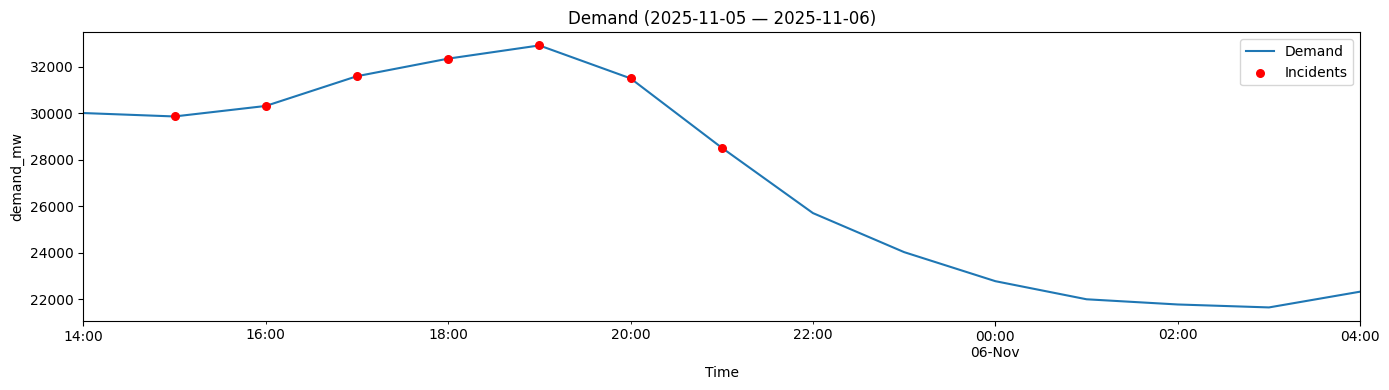

<Axes: title={'center': 'Demand (2025-11-05 — 2025-11-06)'}, xlabel='Time', ylabel='demand_mw'>

In [203]:
# --- Usage ---
df_demand, demand_col = load_demand()
incidents = load_incidents()

# specific period
plot_demand(
    df_demand,
    demand_col,
    incidents=incidents,
    start_date="2025-11-05 15:00:00+01:00",
    end_date="2025-11-06 05:00:00+01:00",
)

In the following plot we can see how the demand changed in that same period during the previous 3 weeks. 

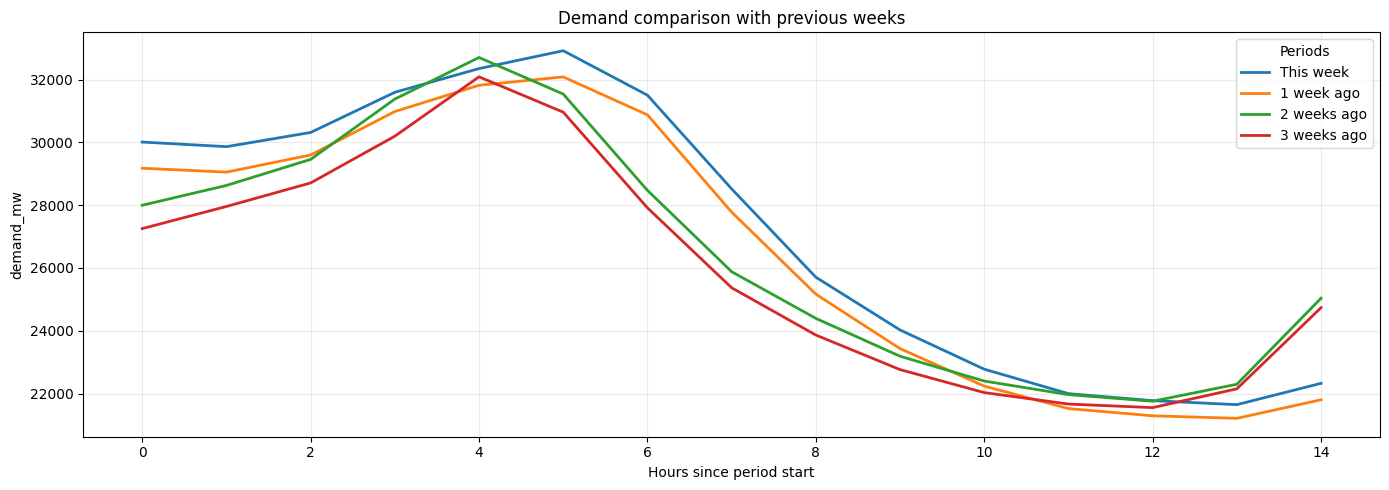

<Axes: title={'center': 'Demand comparison with previous weeks'}, xlabel='Hours since period start', ylabel='demand_mw'>

In [204]:
df_demand, demand_col = load_demand()

# Compare Tuesday from this week with previous Tuesdays in one chart
plot_week_offset_periods(
    df_demand,
    demand_col,
    reference_start="2025-11-05 15:00:00+01:00",
    reference_end="2025-11-06 05:00:00+01:00",
    weeks=[0, 1, 2, 3],
    labels=["This week", "1 week ago", "2 weeks ago", "3 weeks ago"],
)


Notice that the first 'alert' point was at 15hs (see the 'red dots' plot); so an incident happened 6 hours later. In the below plot, where x=6, we can see that the demand of the analyzed period (blue line) reaches a high difference with the others, representing a spike in demand with respect to previous data.